In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm
import pickle

## Loading solved data grids

In [ ]:
# Load Background Solutions
with open("./numpyArr/Rgrid.pkl", "rb") as f:                        
    # binary read
    Rgrid = pickle.load(f)

with open("./numpyArr/PMSol.pkl", "rb") as f:                        
    # binary read
    PMSol = pickle.load(f)

with open("./numpyArr/H00Grid.pkl", "rb") as f:                        
    # binary read
    H00Grid = pickle.load(f)

with open("./numpyArr/NuGrid.pkl", "rb") as f:                        
    # binary read
    NuGrid = pickle.load(f)


## Initialization

In [3]:
# EOS (energy density vs pressure) for n = 1 polytrope
def EnergyEOS(p,K):
    rr=((1+np.sqrt(4*K*p))**2-1)/(4*K)
    return rr

In [4]:
G_cgs = 6.67430e-8     # cm^3 g^-1 s^2
c_cgs = 2.99792458e10  # cm s^-1
M_sun_cgs = 1.989e33   # g
cm2km = 1e5

def cgs_to_geom(p_cgs, n, K_cgs, eos=EnergyEOS):

    # km^-2
    p_geom = p_cgs * G_cgs / c_cgs**4 * cm2km**2            
    # km^(2/n)
    K_geom = K_cgs / G_cgs**(1/n) / c_cgs**(2-2/n) / cm2km**(2/n)               
    # Polytropic EOS, km^-2
    rho_geom = eos(p_geom, K_geom)               

    return K_geom, p_geom, rho_geom

K_cgs = 1.6e5
PcArr = np.logspace(33.5, 36.5, 20)

In [5]:
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]

solToUseID = 3 #
PMSolArr = np.array(PMSol[solToUseID])

# Pick the example background to use
RArr = np.array(Rgrid[solToUseID])
PArr = PMSolArr[:,1]
MArr = PMSolArr[:,0]

# Calculating the rho Array
RhoArr = EnergyEOS(PArr, K)

# Calculating the Lambda Array
LambArr = np.log( RArr/ (RArr-2*MArr) )

print(RArr.shape, PArr.shape, MArr.shape, RhoArr.shape, LambArr.shape)

(55093,) (55093,) (55093,) (55093,) (55093,)


In [6]:
# Calculating the first derivatives of rho, p, and dp/drho
# The last entry of each array in this grid is nan because of the nature of numpy's gradient function

DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
DpArr = np.gradient(PArr, RArr, edge_order=2)
Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)

print(DrhoArr.shape, DpArr.shape, Cs2Arr.shape)

(55093,) (55093,) (55093,)


In [7]:
# Loading h00 solution; these arrays are one dimension less.
H00r = np.array(H00Grid[solToUseID][:,0])
DH00r = np.array(H00Grid[solToUseID][:,1])

print(H00r.shape, DH00r.shape)

(55092,) (55092,)


## Solving for $w_0$

$w_0$ satisfies the equation below:

   $$w_0(r)=  \frac{r h_{00}(r) e^{\frac{\lambda (r)}{2}}}{8 \pi  r^2 p_0(r) e^{\lambda (r)}+e^{\lambda (r)}-1}$$
    

In [8]:
def Ww0(r, pr, h00r, lamb):

    eL = np.exp(lamb)
    eL2 = np.exp(lamb/2)
    pi = np.pi
    
    w_num = r * h00r * eL2

    w_denom = 8 * np.pi * (r**2) * pr * eL + eL - 1

    return w_num/w_denom

In [9]:
W0Sol = np.zeros_like(H00r)

for i in range(0, H00r.shape[0]):
    W0Sol[i] = Ww0(RArr[i], PArr[i], H00r[i], LambArr[i])

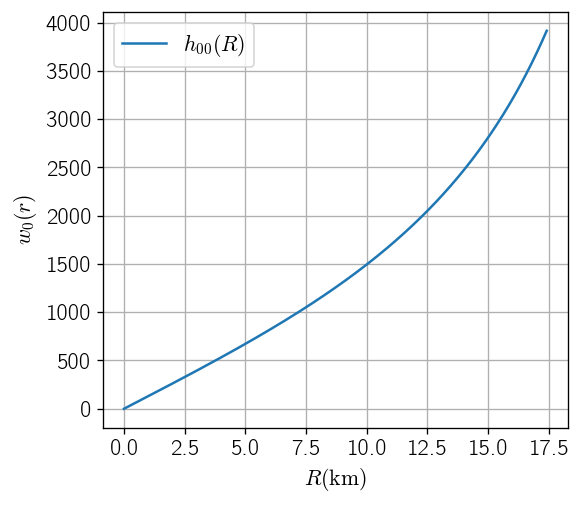

In [10]:
# H00R = np.array([H00Grid[i][-2,0] for i in range(0,20)])
# DH00R = np.array([H00Grid[i][-2,1] for i in range(0,20)])
# RstarArr = np.array([rarr[-2] for rarr in Rgrid])

plt.figure(figsize=(5,4.5), dpi=120)
plt.rcParams["mathtext.fontset"] = "cm"
plt.plot(RArr[:-2], W0Sol[:-1], label=r"$h_{00}(R)$")
# plt.plot(RstarArr, DH00R, label=r"$h_{00}'(R)$")

plt.legend(fontsize=13)
plt.xticks(fontfamily="CMU Bright", fontsize=13)
plt.yticks(fontfamily="CMU Bright", fontsize=13)
plt.ylabel(r"$w_0(r)$", fontfamily="CMU Bright", fontsize=13)
plt.xlabel(r"$R (\text{km})$", fontfamily="CMU Bright", fontsize=13)

plt.grid()

## Creating $w_0$ grid for all 20 stars

In [11]:
W0Grid = []

for nnn in range(0,20):

    # The stellar model used in the current run
    solToUseID = nnn 
    PMSolArr = np.array(PMSol[solToUseID])

    # Pick the example background to use
    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:,1]
    MArr = PMSolArr[:,0]

    # Calculating the rho Array
    RhoArr = EnergyEOS(PArr, K)

    # Calculating the Lambda Array
    LambArr = np.log(RArr/(RArr-2*MArr))

    # Calculating the Sound Speed Array, note this is one dimension less than the original array

    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    DpArr = np.gradient(PArr, RArr, edge_order=2)
    Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)

    H00r = np.array(H00Grid[solToUseID][:,0])
    DH00r = np.array(H00Grid[solToUseID][:,1])

    W0Sol = Ww0(RArr[:-1], PArr[:-1], H00r[:], LambArr[:-1])

    W0Grid.append(W0Sol)

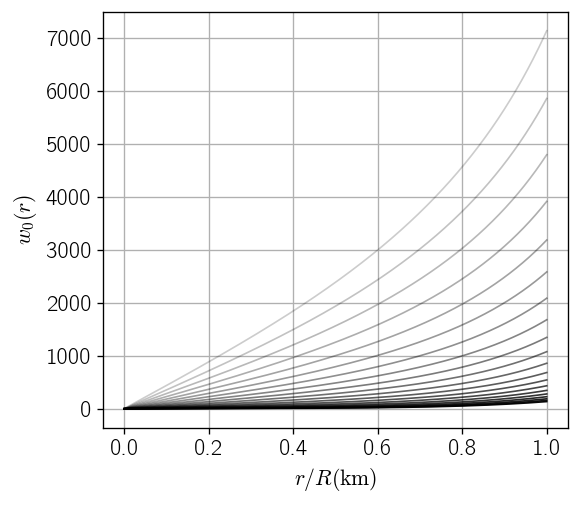

In [12]:


plt.figure(figsize=(5,4.5), dpi=120)
plt.rcParams["mathtext.fontset"] = "cm"

for nnn in range(0,20):

    W0Sol = W0Grid[nnn]
    RArr = np.array(Rgrid[nnn])
    plt.plot(RArr[:-2]/RArr[-2], W0Sol[:-1], lw=1, alpha = 0.2+nnn*0.8/20, ls="-", color="black")



# plt.legend(fontsize=13)
plt.xticks(fontfamily="CMU Bright", fontsize=13)
plt.yticks(fontfamily="CMU Bright", fontsize=13)
plt.ylabel(r"$w_0(r)$", fontfamily="CMU Bright", fontsize=13)
plt.xlabel(r"$r/R (\text{km})$", fontfamily="CMU Bright", fontsize=13)

plt.grid()

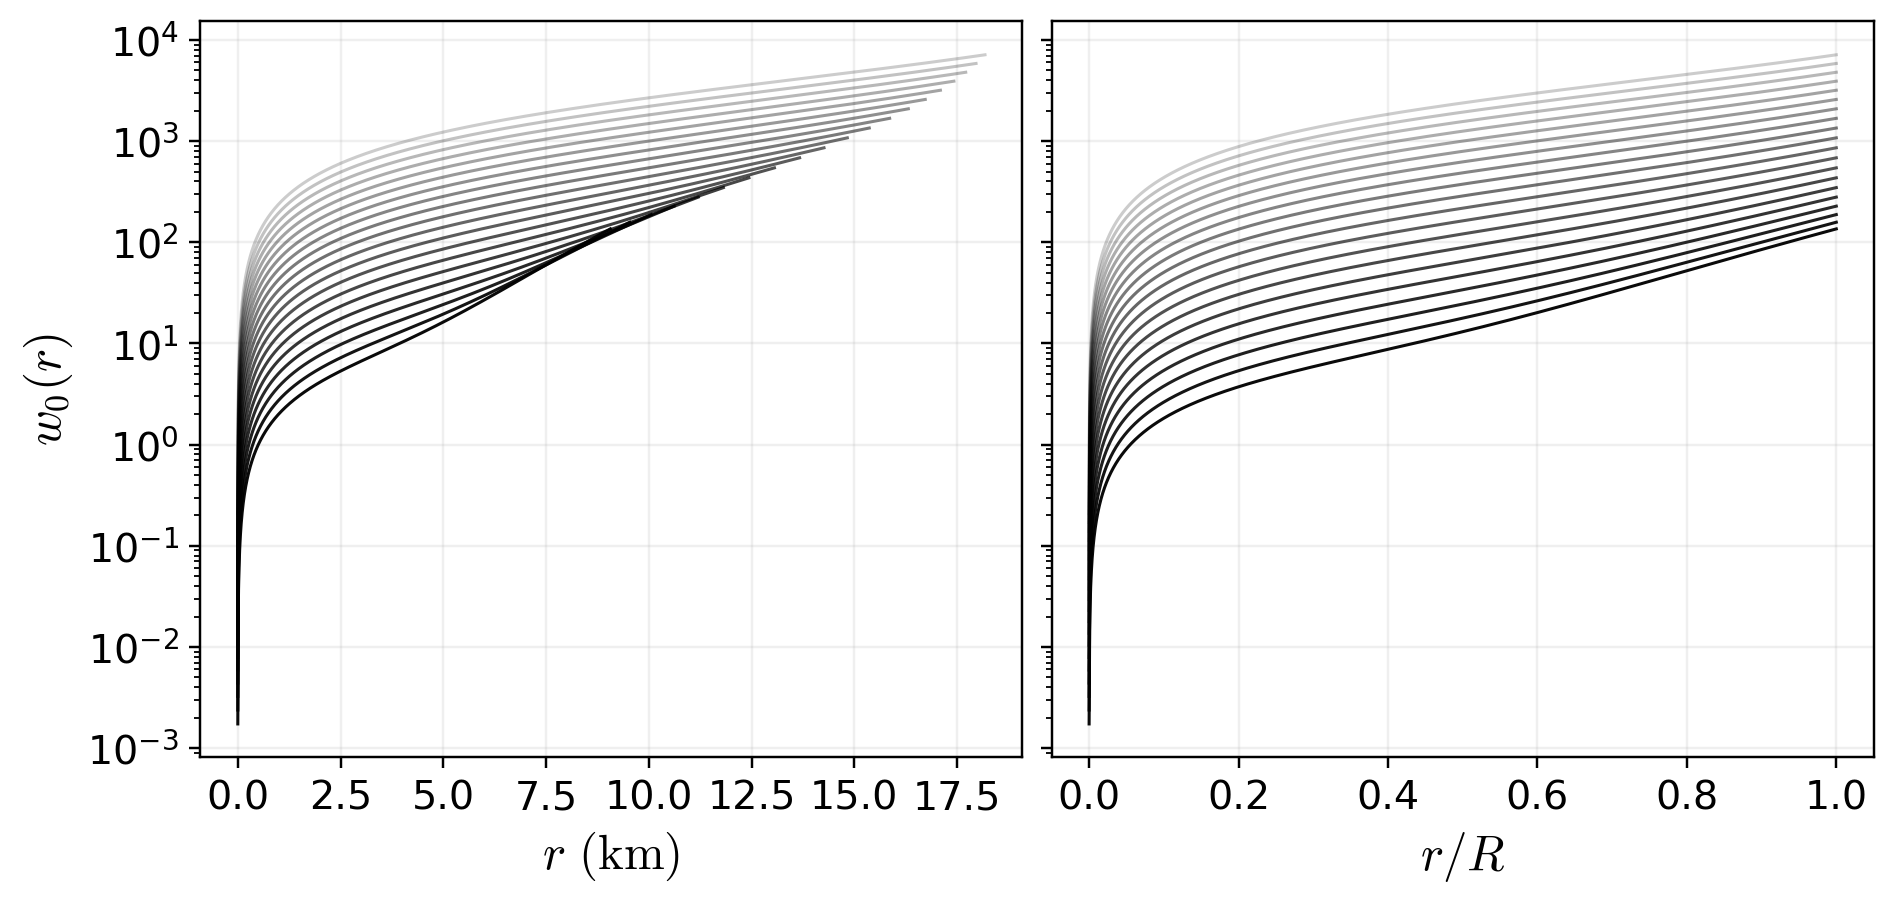

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained", sharey=True)
plt.rcParams["mathtext.fontset"] = "cm"

# --- Left: w0(r) vs r (km) ---
for nnn in range(0, 20):
    W0Sol = W0Grid[nnn]
    RArr = np.array(Rgrid[nnn])
    axs[0].plot(
        RArr[:-2],                 # r (km)
        W0Sol[:-1],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[0].grid(zorder=-100, alpha=0.2)
axs[0].set_xlabel(r"$r\ (\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
axs[0].set_ylabel(r"$w_0(r)$", fontfamily="CMU Bright", fontsize=16)

# --- Right: w0(r) vs r/R (dimensionless) ---
for nnn in range(0, 20):
    W0Sol = W0Grid[nnn]
    RArr = np.array(Rgrid[nnn])
    axs[1].plot(
        RArr[:-2] / RArr[-2],      # r/R
        W0Sol[:-1],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[1].grid(zorder=-100, alpha=0.2)
axs[1].set_yscale("log")
axs[1].set_xlabel(r"$r/R$", fontfamily="CMU Bright", fontsize=16)

# --- Match tick label fonts/sizes on both subplots ---
for ax in axs:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        # lbl.set_fontfamily("CMU Bright")
        lbl.set_fontsize(13)

plt.show()

In [14]:
# with open("./numpyArr/W0Grid.pkl", "wb") as f:                        
#     pickle.dump(W0Grid, f, protocol=pickle.HIGHEST_PROTOCOL)

In [15]:
DW0Grid = []
for i, w0g in enumerate(W0Grid):
    dw0g = np.gradient(w0g, np.array(Rgrid[i][:-1]),  edge_order=2)

    DW0Grid.append(dw0g)

In [16]:
DW0Grid[0]

array([-2.10915064e+01,  1.95200227e+02,  2.65508491e+02, ...,
        9.66513556e+02, -1.12835009e+07, -3.38524358e+07])

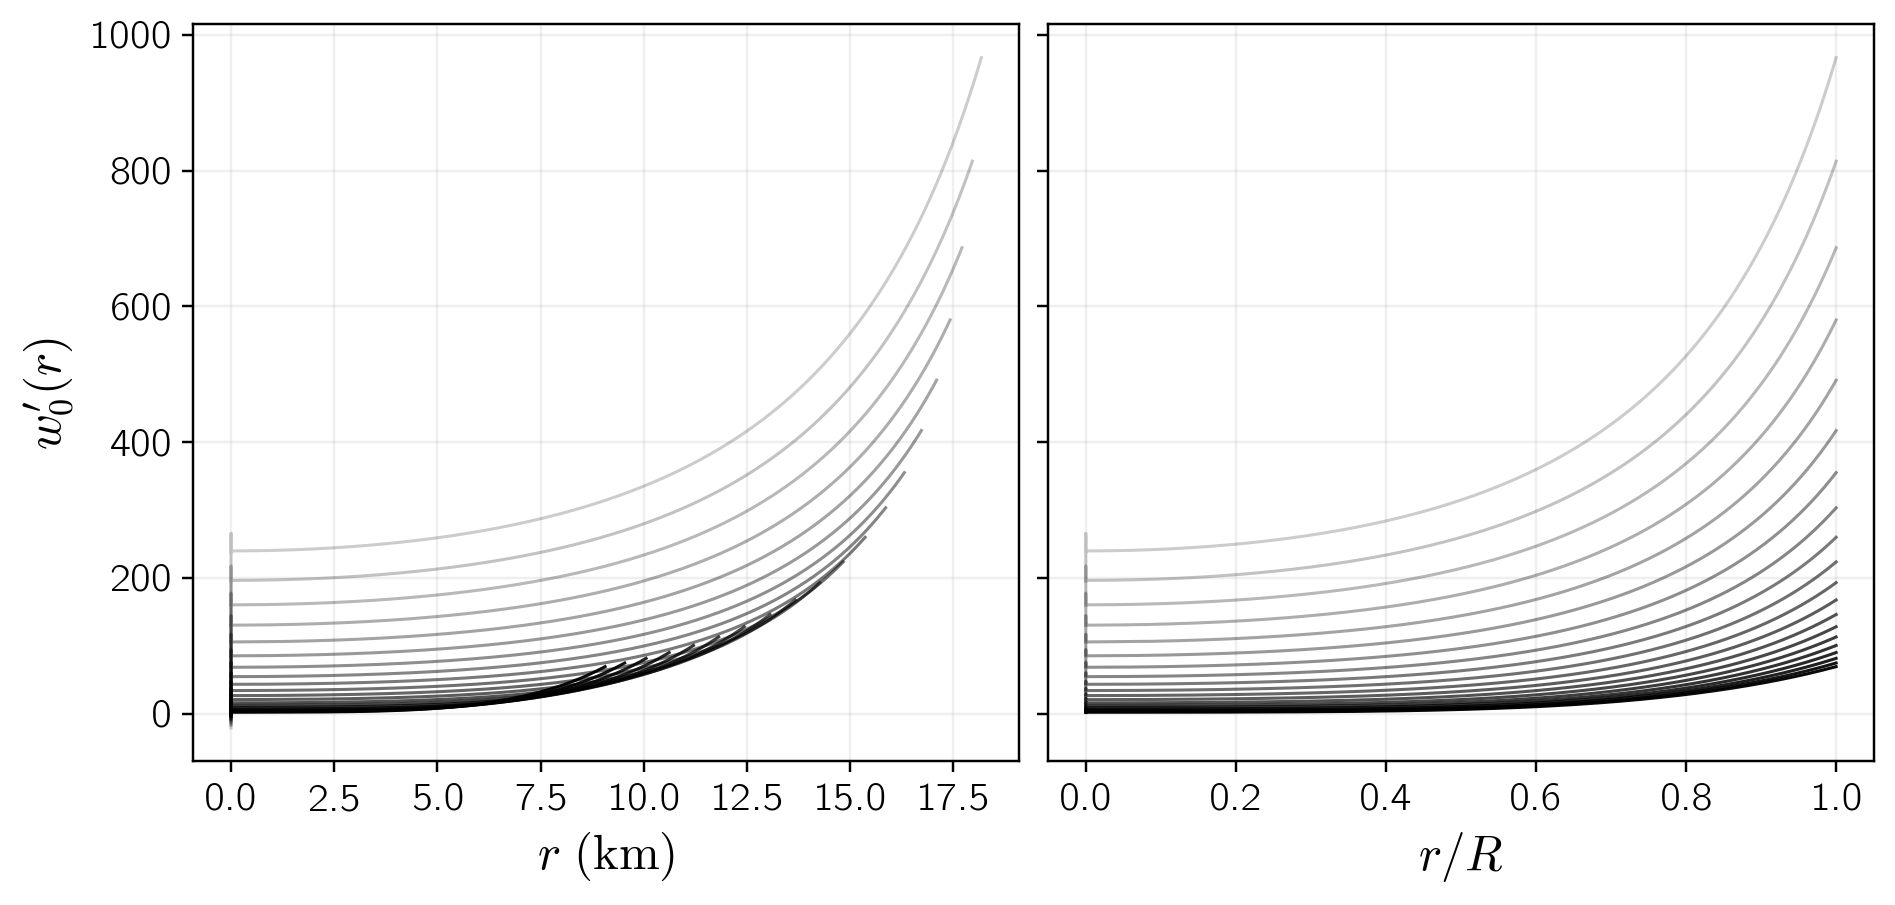

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained", sharey=True)
plt.rcParams["mathtext.fontset"] = "cm"

# --- Left: w0(r) vs r (km) ---
for nnn in range(0, 20):
    DW0Sol = DW0Grid[nnn]
    RArr = np.array(Rgrid[nnn])
    axs[0].plot(
        RArr[:-3],                 # r (km)
        DW0Sol[:-2],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[0].grid(zorder=-100, alpha=0.2)
axs[0].set_xlabel(r"$r\ (\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
axs[0].set_ylabel(r"$w_0'(r)$", fontfamily="CMU Bright", fontsize=16)

# --- Right: w0(r) vs r/R (dimensionless) ---
for nnn in range(0, 20):
    DW0Sol = DW0Grid[nnn]
    RArr = np.array(Rgrid[nnn])
    axs[1].plot(
        RArr[1:-4] / RArr[-2],      # r/R
        DW0Sol[1:-3],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[1].grid(zorder=-100, alpha=0.2)
axs[1].set_xlabel(r"$r/R$", fontfamily="CMU Bright", fontsize=16)

# --- Match tick label fonts/sizes on both subplots ---
for ax in axs:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily("CMU Bright")
        lbl.set_fontsize(13)

plt.show()

In [18]:
# The last two entries are not usable.

with open("./numpyArr/DW0Grid.pkl", "wb") as f:                        
    pickle.dump(DW0Grid, f, protocol=pickle.HIGHEST_PROTOCOL)

## Solve for $V_0(r)$

\begin{align*}
&\frac{e^{-\lambda(r)}\,r}{24\,\tfrac{dp}{d\rho}} \Biggl[
   2\,e^{\tfrac{1}{2}\lambda(r)}
   \Bigl(-1 - 4\,\tfrac{dp}{d\rho}
         + e^{\lambda(r)}\bigl(1+8\pi r^2 p_0(r)\bigr)\Bigr)\,
   w_0(r) \\[6pt]
&\quad + r\,h_{00}(r)\Bigl(
      \tfrac{dp}{d\rho}
      - \tfrac{dp}{d\rho}\,e^{2\lambda(r)}\bigl(1+8\pi r^2 p_0(r)\bigr)^2
      + 2\,e^{\lambda(r)}\Bigl(-1 - 3\tfrac{dp}{d\rho}
             + 4\tfrac{dp}{d\rho}\,\pi r^2 \bigl(3p_0(r)+\rho_0(r)\bigr)
        \Bigr)
   \Bigr) \\[6pt]
&\quad + \tfrac{dp}{d\rho}\,r\Bigl(
      -\,r\Bigl(-1+e^{\lambda(r)}\bigl(1+8\pi r^2 p_0(r)\bigr)\Bigr)\,
         h_{00}'(r)
      - 4\,e^{\tfrac{1}{2}\lambda(r)}\,w_0'(r)
   \Bigr)
\Biggr].
\end{align*}


In [19]:
def Vv0(r, pr, rhor, cs2, lamb, h00r, dh00r, w0r, dw0r):

    eL = np.exp(lamb)
    e2L = np.exp(2*lamb)
    eL2 = np.exp(lamb/2)
    
    
    coeff1 = (1/eL) * r / (24 * cs2)
    # coeff1 = (1/eL) * r / 24

    term1 = 2 * eL2 * (-1 - 4*cs2 + eL*(1 + 8*np.pi*(r**2)*pr)) * w0r
    
    term2 = r * h00r * (cs2 - cs2*e2L * (1 + 8*np.pi*(r**2)*pr)**2)

    term3 = r * h00r * 2*eL*(-1 - 3*cs2 + 4*cs2*np.pi*(r**2)*(3*pr + rhor))

    term4 = cs2*r * (-r)*(-1 + eL * (1+8*np.pi*(r**2)*pr)) * dh00r

    term5 = r * h00r * (4*eL2*dw0r)

    return coeff1 * (term1 + term2 + term3 + term4 + term5)

### Regularized $v_0$

\begin{align*}
&\frac{e^{-\lambda(r)}\,r}{24\,} \Biggl[
   2\,e^{\tfrac{1}{2}\lambda(r)}
   \Bigl(-1 - 4\,\tfrac{dp}{d\rho}
         + e^{\lambda(r)}\bigl(1+8\pi r^2 p_0(r)\bigr)\Bigr)\,
   w_0(r) \\[6pt]
&\quad + r\,h_{00}(r)\Bigl(
      \tfrac{dp}{d\rho}
      - \tfrac{dp}{d\rho}\,e^{2\lambda(r)}\bigl(1+8\pi r^2 p_0(r)\bigr)^2
      + 2\,e^{\lambda(r)}\Bigl(-1 - 3\tfrac{dp}{d\rho}
             + 4\tfrac{dp}{d\rho}\,\pi r^2 \bigl(3p_0(r)+\rho_0(r)\bigr)
        \Bigr)
   \Bigr) \\[6pt]
&\quad + \tfrac{dp}{d\rho}\,r\Bigl(
      -\,r\Bigl(-1+e^{\lambda(r)}\bigl(1+8\pi r^2 p_0(r)\bigr)\Bigr)\,
         h_{00}'(r)
      - 4\,e^{\tfrac{1}{2}\lambda(r)}\,w_0'(r)
   \Bigr)
\Biggr].
\end{align*}

In [20]:
def Vv0_R(r, pr, rhor, cs2, lamb, h00r, dh00r, w0r, dw0r):

    eL = np.exp(lamb)
    e2L = np.exp(2*lamb)
    eL2 = np.exp(lamb/2)
    
    
    # coeff1 = (1/eL) * r / (24 * cs2)
    coeff1 = (1/eL) * r / 24

    term1 = 2 * eL2 * (-1 - 4*cs2 + eL*(1 + 8*np.pi*(r**2)*pr)) * w0r
    
    term2 = r * h00r * (cs2 - cs2*e2L * (1 + 8*np.pi*(r**2)*pr)**2)

    term3 = r * h00r * 2*eL*(-1 - 3*cs2 + 4*cs2*np.pi*(r**2)*(3*pr + rhor))

    term4 = cs2*r * (-r)*(-1 + eL * (1+8*np.pi*(r**2)*pr)) * dh00r

    term5 = r * h00r * (4*eL2*dw0r)

    return coeff1 * (term1 + term2 + term3 + term4 + term5)

## Solve for the zeroth order of $K$, $K_0(r)$

\begin{align*}
K(r) = \frac{1}{4} e^{-\Lambda(r)} \Big[ &
H_0(r) \Big(
   -1 + 4 e^{\Lambda(r)} + e^{2\Lambda(r)} 
   + 8 e^{\Lambda(r)}(-3 + 2 e^{\Lambda(r)}) \pi r^2 p_0(r) \\
& \quad + 64 e^{2\Lambda(r)} \pi^2 r^4 p_0(r)^2
   - 8 e^{\Lambda(r)} \pi r^2 \rho_0(r)
\Big) \\
& \quad + r \Big(-1 + e^{\Lambda(r)} + 8 e^{\Lambda(r)} \pi r^2 p_0(r)\Big)
   H_0'(r)
\Big]
\end{align*}


In [21]:
def Kk0(r, pr, rhor, cs2, lamb, h00r, dh00r, v0r, w0r, dw0r):

    eL = np.exp(lamb)
    eNegL = np.exp(-lamb)
    e2L = np.exp(2 * lamb)
    pi = np.pi

    common = (1/4) * eNegL

    termh1 = (-1 + 4*eL + e2L + 8*eL * (-3 + 2*eL) * pi * (r**2) * pr)
    termh2 = 64 * e2L * (pi**2) * (r**4) * (pr**2)
    termh3 = -8 * eL * pi * (r**2) * rhor

    termH0 = h00r * (termh1 + termh2 + termh3)

    termpH0 = r * (-1 + eL + 8*eL * pi * (r**2) * pr) * dh00r

    return common * (termH0 + termpH0)

In [22]:
def kk0_mathematica(r, p0, rho0, cs2, lamb, H0, dH0, V, W, dW):
    """
    K_k^(0) built from the Mathematica expression supplied by the user.
    All arguments may be scalars or NumPy arrays of matching shape.
    """
    pi = np.pi
    common = p0 + rho0

    eL = np.exp(lamb)
    eNegL = np.exp(-lamb)
    eHalfL = np.exp(0.5 * lamb)
    eThreeHalfL = np.exp(1.5 * lamb)
    e2L = np.exp(2.0 * lamb)

    denom = 4.0 * (-1.0 + 4.0 * cs2 * pi * r**2 * common)

    h0_part = (
        1.0
        - e2L * (1.0 + 8.0 * pi * r**2 * p0) ** 2
        - 4.0 * eL * (1.0 + 2.0 * pi * r**2 * ((-2.0 + cs2) * p0 + cs2 * rho0))
    )

    inner = (
        8.0 * eThreeHalfL * pi * r * (1.0 + 8.0 * pi * r**2 * p0) * W * common
        + dH0
        - eL * (96.0 * cs2 * pi * r * V * common + (1.0 + 8.0 * pi * r**2 * p0) * dH0)
        - 8.0 * eHalfL * pi * r * common * (W * (1.0 + 6.0 * cs2) + 2.0 * cs2 * r * dW)
    )

    return eNegL * (H0 * h0_part + r * inner) / denom

In [23]:
def Kk0_old(r, pr, rhor, cs2, lamb, h00r, dh00r, v0r, w0r, dw0r):

    eL = np.exp(lamb)
    eNegL = np.exp(-lamb)
    e2L = np.exp(2 * lamb)
    eHalfL = np.exp(lamb / 2)
    eThreeHalfL = np.exp(1.5 * lamb)
    pi = np.pi

    common = pr + rhor
    denom = 2.0 * (-1.0 + 4.0 * cs2 * pi * (r ** 2) * common)

    term_base = (-3.0 * h00r
                 + e2L * h00r * (1.0 + 8.0 * pi * (r ** 2) * pr) ** 2
                 - 4.0 * eThreeHalfL * pi * (1.0 + 8.0 * pi * (r ** 2) * pr) * w0r * common
                 - r * dh00r)

    term_eL = eL * (48.0 * cs2 * pi * v0r * common
                   + h00r * (6.0 + 8.0 * cs2 * pi * (r ** 2) * common)
                   + r * (1.0 + 8.0 * pi * (r ** 2) * pr) * dh00r)

    term_eHalf = 4.0 * eHalfL * pi * common * (w0r * (1.0 + 6.0 * cs2) + 2.0 * cs2 * r * dw0r)

    return (eNegL / denom) * (term_base + term_eL + term_eHalf)


## Constructing $V_0$ grid

In [24]:
V0Grid = []

for nnn, HSol, w0g, dw0g in zip(np.arange(0,20), H00Grid, W0Grid, DW0Grid):

    # The stellar model used in the current run
    solToUseID = nnn 
    PMSolArr = np.array(PMSol[solToUseID])

    # Pick the example background to use
    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:,1]
    MArr = PMSolArr[:,0]

    # Calculating the rho Array
    RhoArr = EnergyEOS(PArr, K)

    # Calculating the Lambda Array
    LambArr = np.log(RArr/(RArr-2*MArr))

    # Calculating the Sound Speed Array, note this is one dimension less than the original array

    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    DpArr = np.gradient(PArr, RArr, edge_order=2)
    Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)

    H00r = np.array(HSol[:,0])
    DH00r = np.array(HSol[:,1])

    W0Arr = np.array(w0g)
    DW0Arr = np.array(dw0g)

    V0Sol = Vv0(RArr[:-1], PArr[:-1], RhoArr[:-1], Cs2Arr[:-1], LambArr[:-1], H00r[:], DH00r[:], W0Arr[:], DW0Arr[:])

    V0Grid.append(V0Sol)

    # if nnn == 14:
    #     plt.plot(RArr[:-3], Cs2Arr[:-3])
    #     break
    
    

## Constructing Rescaled $V_0$ grid

In [25]:
V0TGrid = []

for nnn, HSol, w0g, dw0g in zip(np.arange(0,20), H00Grid, W0Grid, DW0Grid):

    # The stellar model used in the current run
    solToUseID = nnn 
    PMSolArr = np.array(PMSol[solToUseID])

    # Pick the example background to use
    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:,1]
    MArr = PMSolArr[:,0]

    # Calculating the rho Array
    RhoArr = EnergyEOS(PArr, K)

    # Calculating the Lambda Array
    LambArr = np.log(RArr/(RArr-2*MArr))

    # Calculating the Sound Speed Array, note this is one dimension less than the original array

    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    DpArr = np.gradient(PArr, RArr, edge_order=2)
    Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)

    H00r = np.array(HSol[:,0])
    DH00r = np.array(HSol[:,1])

    W0Arr = np.array(w0g)
    DW0Arr = np.array(dw0g)

    V0TSol = Vv0_R(RArr[:-1], PArr[:-1], RhoArr[:-1], Cs2Arr[:-1], LambArr[:-1], H00r[:], DH00r[:], W0Arr[:], DW0Arr[:])

    V0TGrid.append(V0TSol)

    # if nnn == 14:
    #     plt.plot(RArr[:-3], Cs2Arr[:-3])
    #     break
    
    

## Constructing $K_0$ grid

In [44]:
K0Grid = []

for nnn, HSol, V0Sol, W0Sol, DW0Sol in zip(np.arange(0,20), H00Grid, V0Grid, W0Grid, DW0Grid):

    solToUseID = nnn 
    PMSolArr = np.array(PMSol[solToUseID])

    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:,1]
    MArr = PMSolArr[:,0]

    RhoArr = EnergyEOS(PArr, K)
    LambArr = np.log(RArr/(RArr-2*MArr))

    Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)

    H00r = np.array(HSol[:,0])
    DH00r = np.array(HSol[:,1])

    V0Arr = np.array(V0Sol)
    W0Arr = np.array(W0Sol)
    DW0Arr = np.array(DW0Sol)

    K0Sol = Kk0(RArr[:-1], PArr[:-1], RhoArr[:-1], Cs2Arr[:-1], LambArr[:-1], H00r[:], DH00r[:], V0Arr[:], W0Arr[:], DW0Arr[:])

    K0Grid.append(K0Sol)


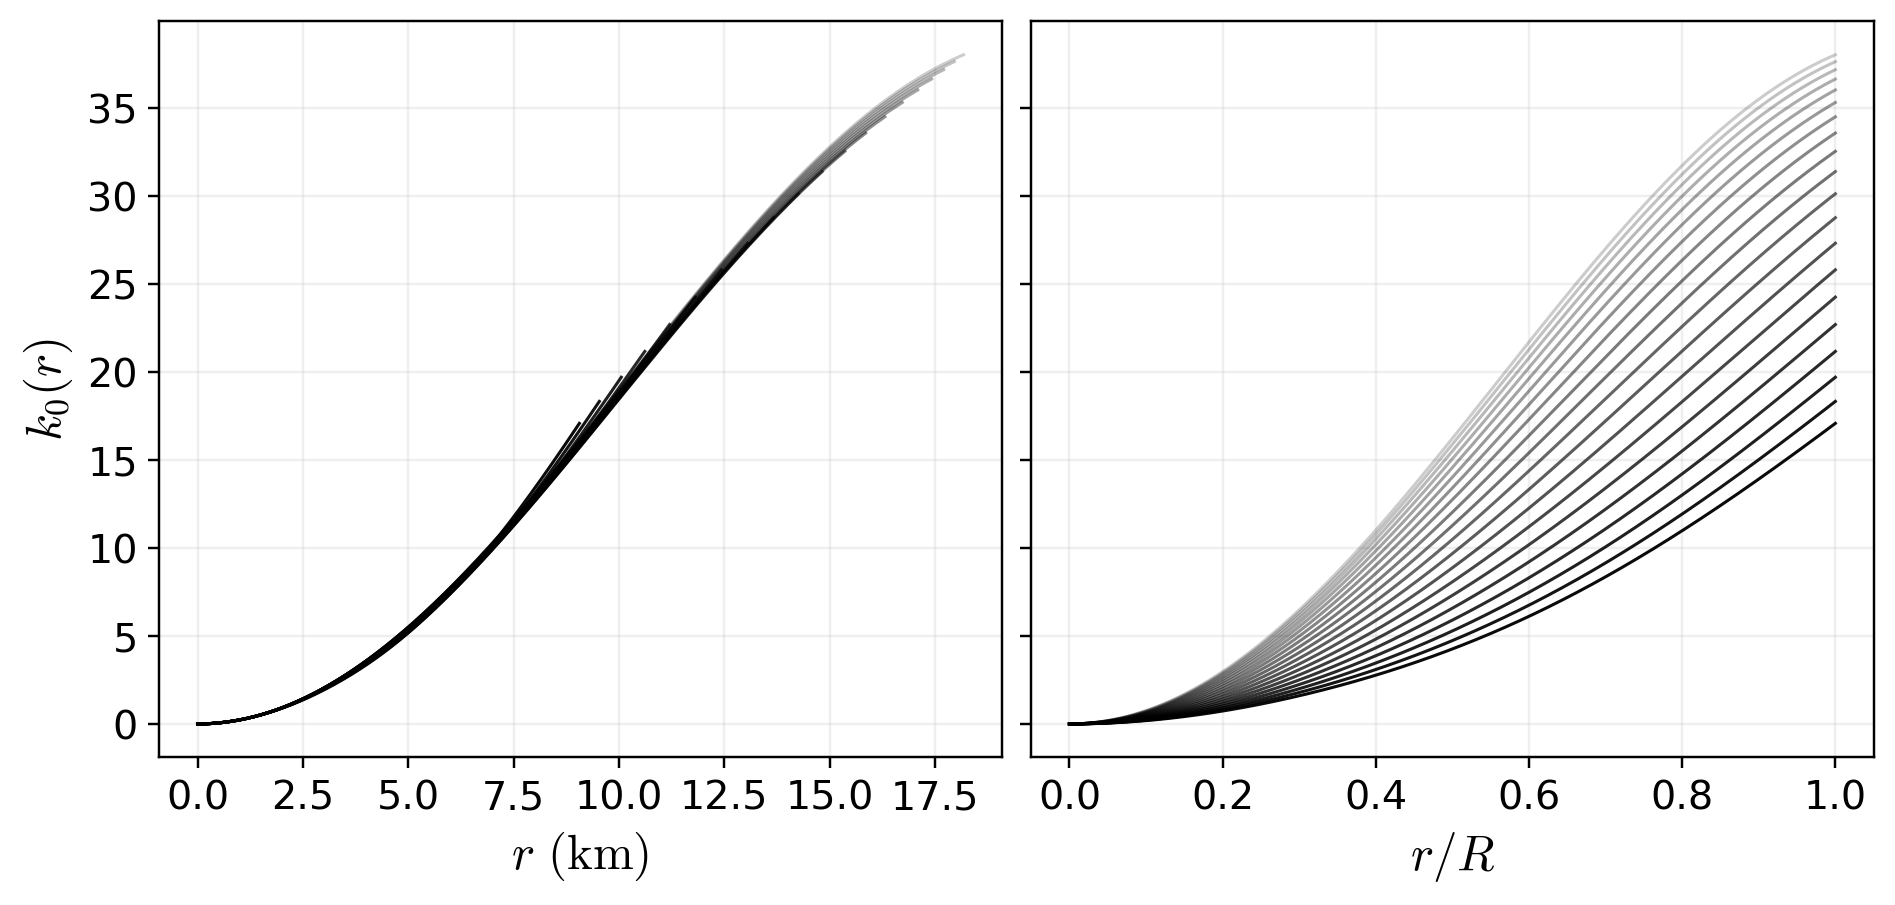

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained", sharey=True)
plt.rcParams["mathtext.fontset"] = "cm"

for nnn in range(0, 20):
    K0Sol = np.array(K0Grid[nnn])
    RArr = np.array(Rgrid[nnn])
    r_vals = RArr[:K0Sol.shape[0]]

    axs[0].plot(
        r_vals[:-2],
        K0Sol[:-2],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

    axs[1].plot(
        r_vals[:-2] / RArr[-2],
        K0Sol[:-2],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[0].grid(zorder=-100, alpha=0.2)
axs[0].set_xlabel(r"$r\ (\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
axs[0].set_ylabel(r"$k_0(r)$", fontfamily="CMU Bright", fontsize=16)

axs[1].grid(zorder=-100, alpha=0.2)
axs[1].set_xlabel(r"$r/R$", fontfamily="CMU Bright", fontsize=16)

for ax in axs:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontsize(13)

plt.show()


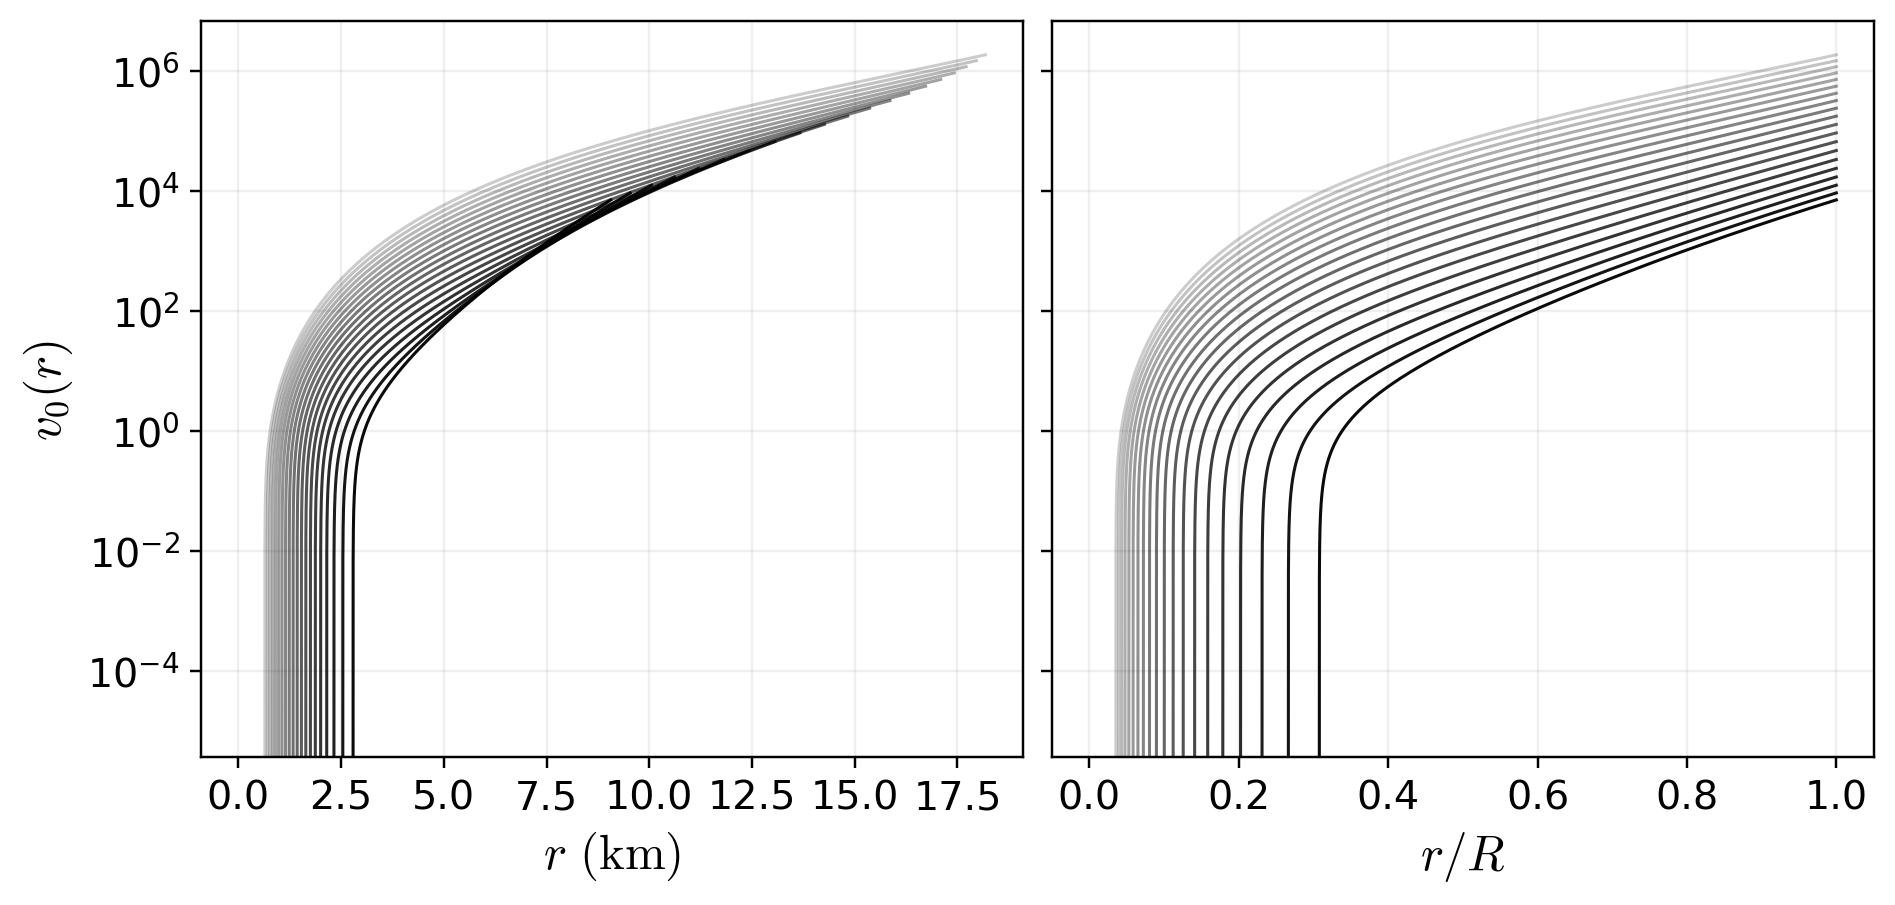

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained", sharey=True)
plt.rcParams["mathtext.fontset"] = "cm"


for nnn in range(0, 20):
    V0TSol = V0TGrid[nnn]
    RArr = np.array(Rgrid[nnn])
    axs[0].plot(
        RArr[:-5],                 # r (km)
        V0TSol[:-4],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[0].grid(zorder=-100, alpha=0.2)
# axs[0].set_yscale("log")
# axs[0].set_ylim(-20, 10)
axs[0].set_xlabel(r"$r\ (\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
axs[0].set_ylabel(r"$v_0(r)$", fontfamily="CMU Bright", fontsize=16)

# --- Right: v0t(r) vs r/R (dimensionless) ---
for nnn in range(0, 20):
    V0TSol = V0TGrid[nnn]
    RArr = np.array(Rgrid[nnn])
    axs[1].plot(
        RArr[:-4] / RArr[-2],      # r/R
        V0TSol[:-3],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[1].grid(zorder=-100, alpha=0.2)
axs[1].set_xlabel(r"$r/R$", fontfamily="CMU Bright", fontsize=16)

# --- Match tick label fonts/sizes on both subplots ---
for ax in axs:
    ax.set_yscale("log")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        # lbl.set_fontfamily("CMU Bright")
        lbl.set_fontsize(13)

plt.show()

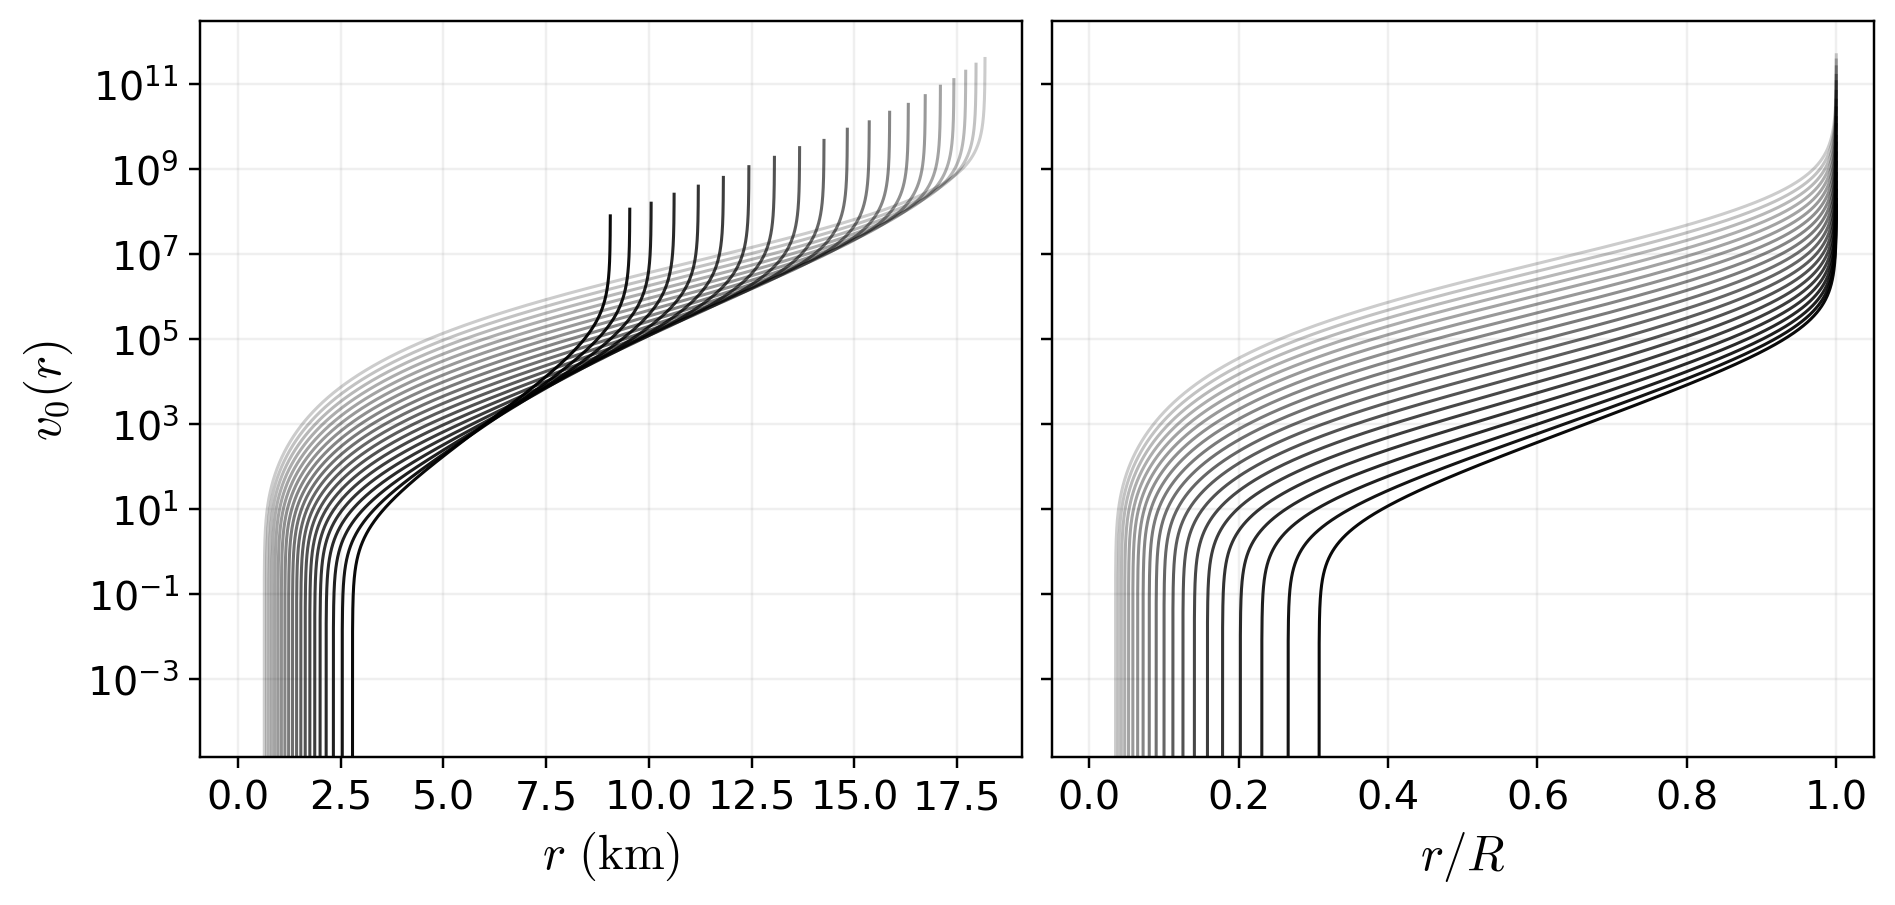

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained", sharey=True)
plt.rcParams["mathtext.fontset"] = "cm"

# --- Left: w0(r) vs r (km) ---
for nnn in range(0, 20):
    V0Sol = V0Grid[nnn]
    RArr = np.array(Rgrid[nnn])
    axs[0].plot(
        RArr[:-5],                 # r (km)
        V0Sol[:-4],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[0].grid(zorder=-100, alpha=0.2)
# axs[0].set_yscale("log")
# axs[0].set_ylim(-20, 10)
axs[0].set_xlabel(r"$r\ (\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
axs[0].set_ylabel(r"$v_0(r)$", fontfamily="CMU Bright", fontsize=16)

# --- Right: w0(r) vs r/R (dimensionless) ---
for nnn in range(0, 20):
    V0Sol = V0Grid[nnn]
    RArr = np.array(Rgrid[nnn])
    axs[1].plot(
        RArr[:-4] / RArr[-2],      # r/R
        V0Sol[:-3],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[1].grid(zorder=-100, alpha=0.2)
axs[1].set_xlabel(r"$r/R$", fontfamily="CMU Bright", fontsize=16)

# --- Match tick label fonts/sizes on both subplots ---
for ax in axs:
    ax.set_yscale("log")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        # lbl.set_fontfamily("CMU Bright")
        lbl.set_fontsize(13)

plt.show()

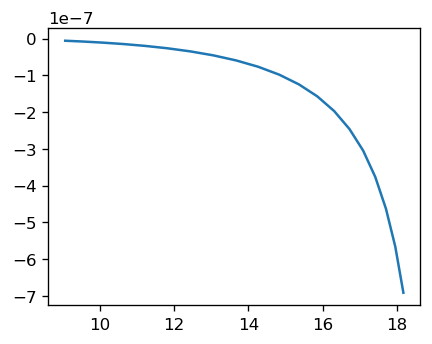

In [48]:
# V0 at the surface

V0R0 = []
Rstar = []

for nnn in range(0, 20):
    V0Sol = V0Grid[nnn]
    V0R0.append(V0Sol[0])

    RArr = np.array(Rgrid[nnn])
    Rstar.append(RArr[-1])

plt.figure(figsize=(4,3),dpi=120)
plt.plot(Rstar, V0R0)

## Source term of the first order equations

An operator for the homogeneous equation takes the form:
\begin{align*}
    \mathcal{L}(h_{00}, w_0) = A_1h_{00} + A_2h_{00} + h'_{00} + A_4w_{0}
\end{align*}
where the coefficients are respectively given by:
\begin{align*}
    A_1(r) &= -\frac{1}{r^{2}p_0(r)\Gamma[\rho_0(r)]}\Biggl(
    64\,e^{2\Lambda(r)}\pi^{2} r^{4} p_0(r)^{3}\Gamma[\rho_0(r)]
    +4\,e^{\Lambda(r)}\pi r^{2} p_0(r)^{2}\bigl[-1+(-13+4e^{\Lambda(r)})\Gamma[\rho_0(r)]\bigr] \notag\\
    &\quad -4\,e^{\Lambda(r)}\pi r^{2}\rho_0(r)^{2}
    +p_0(r)\Bigl(-8\,e^{\Lambda(r)}\pi r^{2}\rho_0(r)
    +\Gamma[\rho_0(r)](1+4e^{\Lambda(r)}+e^{2\Lambda(r)}-20e^{\Lambda(r)}\pi r^{2}\rho_0(r))\Bigr)
    \Biggr), \\[1em]
    A_2(r) &= \frac{1}{r}\Bigl(1+e^{\Lambda(r)}+4e^{\Lambda(r)}\pi r^{2}[p_0(r)-\rho_0(r)]\Bigr), \\[1em]
    A_3(r) &= 1, \\[1em]
    A_4(r) &= -\frac{4\pi e^{\Lambda(r)/2}}{r\,p_0(r)\Gamma[\rho_0(r)]}\Biggl(
    8e^{\Lambda(r)}\pi r^{2} p_0(r)^{3}
    +(-1+e^{\Lambda(r)})\rho_0(r)^{2}
    +p_0(r)^{2}\bigl[-1+e^{\Lambda(r)}+16e^{\Lambda(r)}\pi r^{2}\rho_0(r)\bigr] \notag\\
    &\quad +2p_0(r)\bigl[(-1+e^{\Lambda(r)})\rho_0(r)
    +4e^{\Lambda(r)}\pi r^{2}\rho_0(r)^{2}
    +r\Gamma[\rho_0(r)]\rho_0'(r)\bigr]
    \Biggr).
\end{align*}

I have checked the consistency in my Mathematica notebook.

Now we compute the source term of the first order equation.

### Viscous Source Implementation
We evaluate the source term with `Source(...)`, which
wraps the viscous coefficients from Saketh et al. and takes the profiles
`h_{20}=h_{00}`, `k_0`, `v_0`, and `w_0` together with their radial
derivatives. This keeps the homogeneous operator defined above intact while
making it easy to tune the transport coefficients or reuse tabulated
backgrounds.


\begin{align*}
S_{w_0}(r) = &\; -\frac{4 i \pi\, e^{-\nu(r)/2} \rho_0(r)}{3 c_s^2 r^2 T^2 \omega} \Bigg[ 18 c_s^2 e^{2\lambda(r)}\eta_c \omega_r(r)^2 v_0(r) \rho_0(r) \\& - 12 c_s^2 e^{3\lambda(r)/2} \eta_c\, r \omega^2 \bigl(1 + 8 \pi r^2 p_0(r)\bigr) w_0(r) \rho_0(r) \\& + e^{\lambda(r)} \Big( r^2 \mathrm{coeff}_A(r)\, h_{20}(r) \rho_0(r) + 2 r^2 \mathrm{coeff}_B(r)\, k_0(r) \rho_0(r) \\& \qquad + 6 v_0(r) \rho_0(r) \bigl( \mathrm{coeff}_C(r) - \Delta_v(r) \bigr) \\& \qquad + 3 (1 + 3 c_s^2) \eta_c r \omega^2 \bigl(-1 + 8 \pi r^2 \rho_0(r)\bigr) v_0'(r) \\& \qquad - 24 c_s^2 \eta_c r \omega^2 \bigl(1 + 8 \pi r^2 p_0(r)\bigr) v_0(r) \rho_0'(r) \Big) \\& + 2 e^{\lambda(r)/2} r \Big( \mathrm{coeff}_D(r) \rho_0(r) w_0'(r) + 2 w_0(r) \bigl( \mathrm{coeff}_E(r) \rho_0(r) + 3(1 + 3 c_s^2) \eta_c r \omega^2 \rho_0'(r) \bigr) \Big) \\& + 3 \eta_c \omega^2 \Big( 2 v_0(r) \bigl[(1 + 6 c_s^2) \rho_0(r) + 4(1 + 4 c_s^2) r \rho_0'(r)\bigr] \\& \qquad + (1 + 3 c_s^2) r \Big[ v_0'(r) \big( \rho_0(r) - 4 r \rho_0'(r) \big) - 2 r \rho_0(r) v_0''(r) \Big] \Big) \Bigg].
\end{align*}

Here
\begin{align*}
\omega_r(r) &= \omega \Bigl(1 + 8 \pi r^2 p_0(r)\bigr), \\
\Delta_v(r) &= 8 \eta_c \pi r^2 \omega^2 \bigl(18 c_s^2 p_0(r) + (1 + 7 c_s^2) \rho_0(r)\bigr), \\
\mathrm{coeff}_A(r) &= 3 T^8 \zeta_c - 2 (1 + 3 c_s^2) \eta_c \omega^2, \\
\mathrm{coeff}_B(r) &= 3 T^8 \zeta_c + (1 + 3 c_s^2) \eta_c \omega^2, \\
\mathrm{coeff}_C(r) &= 6 T^8 \zeta_c + (7 + 15 c_s^2) \eta_c \omega^2, \\
\mathrm{coeff}_D(r) &= 3 T^8 \zeta_c + (1 + 3 c_s^2) \eta_c \omega^2, \\
\mathrm{coeff}_E(r) &= 3 T^8 \zeta_c + (4 + 15 c_s^2) \eta_c \omega^2
\end{align*}


**Source term** has viscosity dependency and is 0 when set to the non-viscous limit. We make use of expressions for bulk and shear viscosity in Saketh's paper:
$$\zeta_{\mathrm{m-Urca}} = 6\times 10^{-61}\rho^2T^6/\omega^2$$
$$\eta_{ee} = 6\times 10^6\rho^2T^{-2}$$

In [49]:
def Source(r, pr, rhor, drhor, cs2, lamb, nu, h20r, k0r, v0r, dv0r, d2v0r, w0r, dw0r,
               EtaC=6e6, ZetaC=6e-61, T=1.0, omega=1.0):
    """Return the viscous source term S_{w0}(r) expressed with the coefficient shorthands

    defined in the accompanying markdown.

    """
    pi = np.pi
    I = 1j

    eL = np.exp(lamb)
    e2L = np.exp(2.0 * lamb)
    eHalfL = np.exp(0.5 * lamb)
    eThreeHalfL = np.exp(1.5 * lamb)
    eNegNuHalf = np.exp(-0.5 * nu)

    omega_sq = omega ** 2
    T2 = T ** 2
    T8 = T ** 8

    common_rho = rhor

    prefactor = - (4.0 * I * pi * eNegNuHalf * common_rho) / (3.0 * cs2 * (r ** 2) * T2 * omega)

    omega_term = omega * (1.0 + 8.0 * pi * (r ** 2) * pr)
    term1 = 18.0 * cs2 * e2L * EtaC * (omega_term ** 2) * v0r * common_rho

    term2 = -12.0 * cs2 * eThreeHalfL * EtaC * r * omega_sq * (1.0 + 8.0 * pi * (r ** 2) * pr) * w0r * common_rho

    coeff_A = 3.0 * T8 * ZetaC - 2.0 * (1.0 + 3.0 * cs2) * EtaC * omega_sq
    coeff_B = 3.0 * T8 * ZetaC + (1.0 + 3.0 * cs2) * EtaC * omega_sq
    coeff_C = 6.0 * T8 * ZetaC + (7.0 + 15.0 * cs2) * EtaC * omega_sq
    coeff_D = 3.0 * T8 * ZetaC + (1.0 + 3.0 * cs2) * EtaC * omega_sq
    coeff_E = 3.0 * T8 * ZetaC + (4.0 + 15.0 * cs2) * EtaC * omega_sq

    coeffA_term = (r ** 2) * coeff_A * h20r * common_rho
    coeffB_term = 2.0 * (r ** 2) * coeff_B * k0r * common_rho
    v0_corr = 8.0 * EtaC * pi * (r ** 2) * omega_sq * (18.0 * cs2 * pr + (1.0 + 7.0 * cs2) * common_rho)
    coeffC_term = 6.0 * v0r * common_rho * (coeff_C - v0_corr)
    dv0_term = 3.0 * (1.0 + 3.0 * cs2) * EtaC * r * omega_sq * common_rho * (-1.0 + 8.0 * pi * (r ** 2) * common_rho) * dv0r
    rho_grad_term = 24.0 * cs2 * EtaC * r * omega_sq * (1.0 + 8.0 * pi * (r ** 2) * pr) * v0r * drhor
    term3 = eL * (coeffA_term + coeffB_term + coeffC_term + dv0_term - rho_grad_term)

    coeffD_term = coeff_D * common_rho * dw0r
    coeffE_term = coeff_E * common_rho
    density_gradient_coupling = 3.0 * (1.0 + 3.0 * cs2) * EtaC * r * omega_sq * drhor
    term4_inner = r * (coeffD_term + 2.0 * w0r * (coeffE_term + density_gradient_coupling))
    term4 = 2.0 * eHalfL * term4_inner

    density_combo = (1.0 + 6.0 * cs2) * common_rho + 4.0 * (1.0 + 4.0 * cs2) * r * drhor
    derivative_combo = dv0r * (common_rho - 4.0 * r * drhor) - 2.0 * r * common_rho * d2v0r
    term5 = 3.0 * EtaC * omega_sq * (2.0 * v0r * density_combo + (1.0 + 3.0 * cs2) * r * derivative_combo)

    total = term1 + term2 + term3 + term4 + term5
    return prefactor * total



### Source term with $v$ related terms removed

$$
\text{SourceNoV}(r) =
-\frac{4 i \pi e^{(\lambda(r) - \nu(r))/2}\,\rho_0(r)}{3\,r\,T^2\,\omega\,c_s^2(r)}
\left[
\begin{aligned}
&\; e^{\lambda(r)/2} r \left(3 T^8 \zeta_C - 2 \eta_C \omega^2 - 6 \eta_C \omega^2 c_s^2(r)\right) h_{20}(r)\,\rho_0(r) \\
&+ 2 e^{\lambda(r)/2} r \left(3 T^8 \zeta_C + \eta_C \omega^2 + 3 \eta_C \omega^2 c_s^2(r)\right) k_0(r)\,\rho_0(r) \\
&+ 2 r \left(3 T^8 \zeta_C + \eta_C \omega^2 + 3 \eta_C \omega^2 c_s^2(r)\right) \rho_0(r)\, w_0'(r) \\
&+ 4 w_0(r) \Big(
  \left(3 T^8 \zeta_C + 4 \eta_C \omega^2 - 3 \eta_C \omega^2 c_s^2(r)\left(-5 + e^{\lambda(r)}\left(1 + 8 \pi r^2 p_0(r)\right)\right)\right) \rho_0(r) \\
&\hspace{4.4em}{}+ 3 \eta_C r \omega^2 \left(1 + 3 c_s^2(r)\right) \rho_0'(r)
\Big)
\end{aligned}
\right].
$$

In [50]:
def SourceNoV(r, pr, rhor, drhor, cs2, lamb, nu, h20r, k0r, v0r, dv0r, d2v0r, w0r, dw0r,
              EtaC=6e6, ZetaC=6e-61, T=1.0, omega=1.0):
    """
    Viscous source term with the V-dependent pieces removed, following the Mathematica result. Arguments match `Source`.
    """
    pi = np.pi
    I = 1j

    omega_sq = omega ** 2
    T2 = T ** 2
    T8 = T ** 8

    eL = np.exp(lamb)
    eHalfL = np.exp(0.5 * lamb)
    eNuHalf = np.exp(-0.5 * nu)

    prefactor = (4.0 * I * pi * eHalfL * eNuHalf * rhor) / (3.0 * r * T2 * omega * cs2)

    coeff_a = 3.0 * T8 * ZetaC - 2.0 * EtaC * omega_sq * (1.0 + 3.0 * cs2)
    coeff_b = 3.0 * T8 * ZetaC + EtaC * omega_sq * (1.0 + 3.0 * cs2)

    term1 = eHalfL * r * coeff_a * h20r * rhor
    term2 = 2.0 * eHalfL * r * coeff_b * k0r * rhor
    term3 = 2.0 * r * coeff_b * rhor * dw0r

    inner = (3.0 * T8 * ZetaC + 4.0 * EtaC * omega_sq
             - 3.0 * EtaC * omega_sq * cs2 * (-5.0 + eL * (1.0 + 8.0 * pi * r ** 2 * pr))) * rhor
    inner += 3.0 * EtaC * r * omega_sq * (1.0 + 3.0 * cs2) * drhor
    term4 = 4.0 * w0r * inner

    return -prefactor * (term1 + term2 + term3 + term4)

In [51]:
SourceNoVGrid = []
T_visc = 10 ** 5.5

for nnn, HSol, V0Sol, W0Sol, DW0Sol, K0Sol, nu_prof in zip(
    np.arange(0, 20), H00Grid, V0Grid, W0Grid, DW0Grid, K0Grid, NuGrid
):

    PMSolArr = np.array(PMSol[nnn])
    RArr = np.array(Rgrid[nnn])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]

    RhoArr = EnergyEOS(PArr, K)
    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    Cs2Arr = np.gradient(PArr, RArr, edge_order=2)
    LambArr = np.log(RArr / (RArr - 2.0 * MArr))

    nu_eval = np.asarray(nu_prof)
    slice_len = nu_eval.shape[0]

    r_eval = RArr[:slice_len]
    pr_eval = PArr[:slice_len]
    rho_eval = RhoArr[:slice_len]
    drho_eval = DrhoArr[:slice_len]
    cs2_eval = Cs2Arr[:slice_len]
    lamb_eval = LambArr[:slice_len]

    h20_eval = np.array(HSol[:, 0])[:slice_len]
    k0_eval = np.array(K0Sol)[:slice_len]
    v0_eval = np.array(V0Sol)[:slice_len]
    w0_eval = np.array(W0Sol)[:slice_len]
    dw0_eval = np.array(DW0Sol)[:slice_len]

    dv0_eval = np.gradient(v0_eval, r_eval, edge_order=2)
    d2v0_eval = np.gradient(dv0_eval, r_eval, edge_order=2)

    source_vals = SourceNoV(
        r_eval,
        pr_eval,
        rho_eval,
        drho_eval,
        cs2_eval,
        lamb_eval,
        nu_eval,
        h20_eval,
        k0_eval,
        v0_eval,
        dv0_eval,
        d2v0_eval,
        w0_eval,
        dw0_eval,
        T=T_visc
    )

    SourceNoVGrid.append(source_vals)



<>:30: SyntaxWarning: invalid escape sequence '\,'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\,'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_90772/231636334.py:30: SyntaxWarning: invalid escape sequence '\,'
  axs[0].set_xlabel("$r\,(\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_90772/231636334.py:31: SyntaxWarning: invalid escape sequence '\o'
  axs[0].set_ylabel("$\operatorname{Im} S_{v\mathrm{-independent}}(r)$", fontfamily="CMU Bright", fontsize=16)


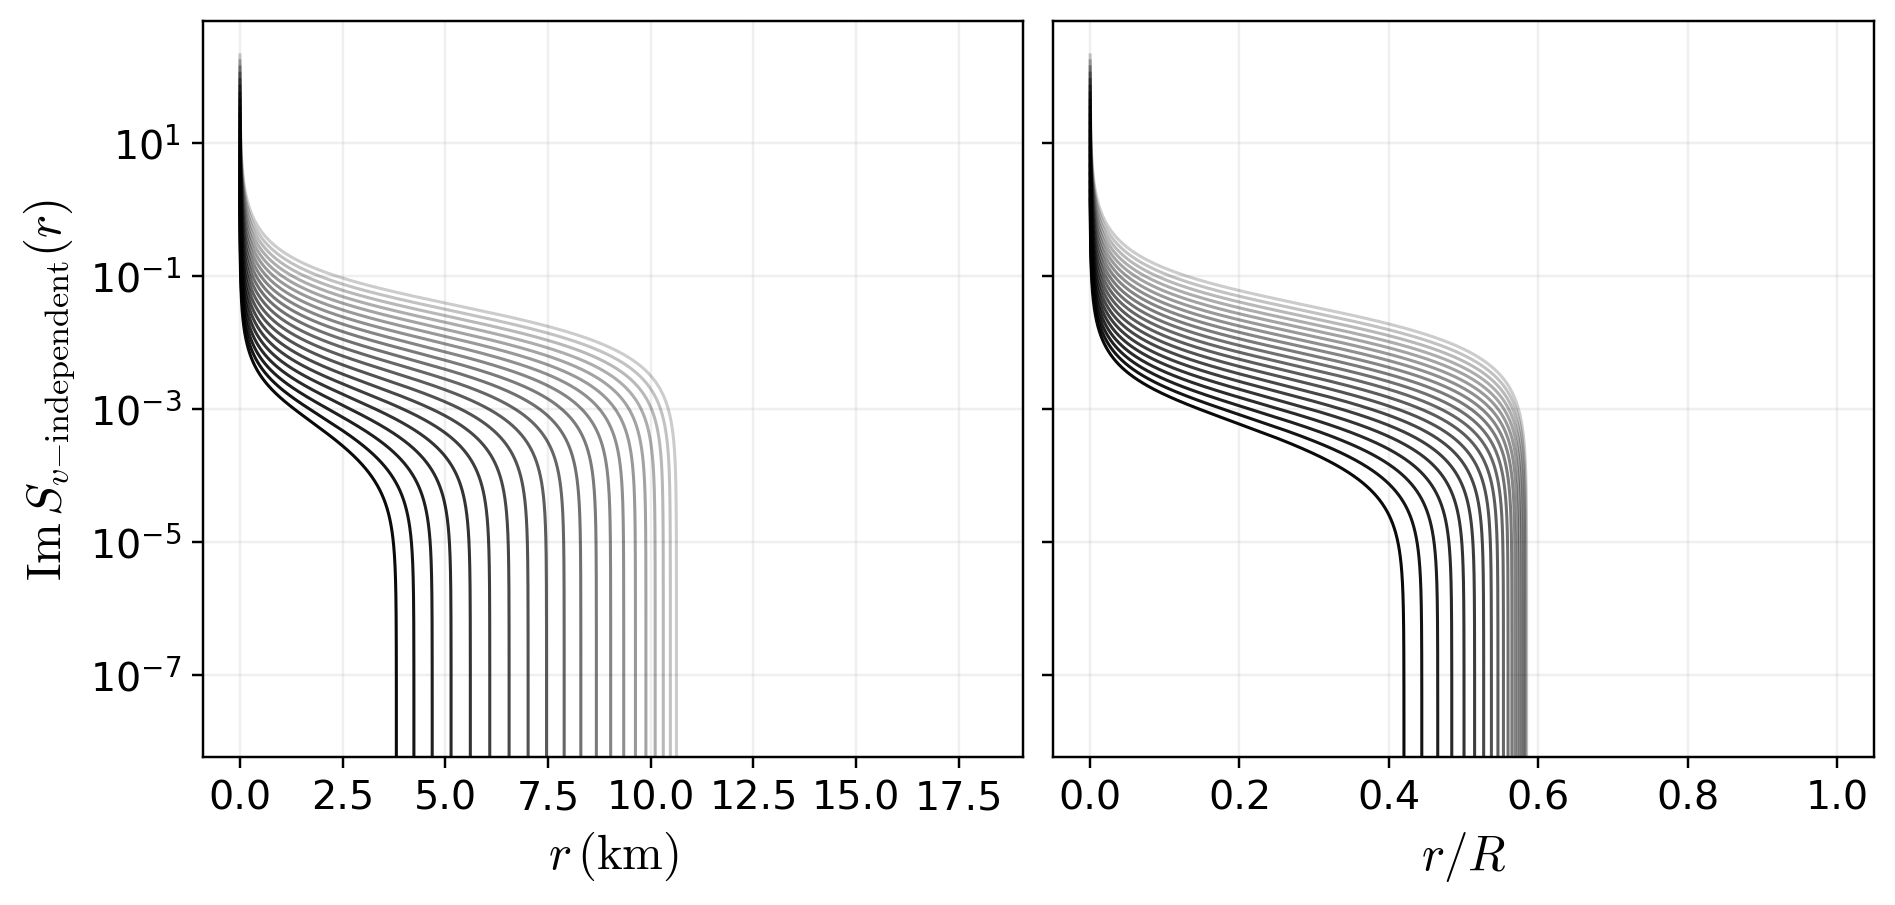

In [52]:

fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained", sharey=True)
plt.rcParams["mathtext.fontset"] = "cm"

for nnn in range(0, 20):
    sourceNoV_vals = np.array(SourceNoVGrid[nnn])
    RArr = np.array(Rgrid[nnn])
    r_eval = RArr[:sourceNoV_vals.shape[0]]

    axs[0].plot(
        r_eval[5:-50],
        np.imag(sourceNoV_vals)[5:-50],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

    axs[1].plot(
        r_eval[5:-50] / RArr[-2],
        np.imag(sourceNoV_vals)[5:-50],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[0].grid(zorder=-100, alpha=0.2)
axs[0].set_xlabel("$r\,(\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
axs[0].set_ylabel("$\operatorname{Im} S_{v\mathrm{-independent}}(r)$", fontfamily="CMU Bright", fontsize=16)

axs[1].grid(zorder=-100, alpha=0.2)
axs[1].set_xlabel("$r/R$", fontfamily="CMU Bright", fontsize=16)

for ax in axs:
    ax.set_yscale("log")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontsize(13)

plt.show()

### SourceTerm with only $v$ related

In [58]:
import numpy as np

def SourceOnlyVR(r, pr, rhor, drhor, cs2, lamb, nu,
                 h20r, k0r, vtr, dvtr, d2vtr, w0r, dw0r,
                 EtaC=6e6, ZetaC=6e-61, T=1.0, omega=1.0):
    """
    Viscous source term that keeps only the pieces proportional to V_t and its derivatives (Mathematica expression).  The argument list
    mirrors `Source`, except that the `v0r` inputs have been renamed to `vtr`.
    Unused arguments (h20r, k0r, w0r, dw0r) are accepted for interface
    compatibility.
    """
    pi = np.pi
    I = 1j

    r = np.asarray(r)
    cs2 = np.asarray(cs2)
    rhor = np.asarray(rhor)
    drhor = np.asarray(drhor)
    vtr = np.asarray(vtr)
    dvtr = np.asarray(dvtr)
    d2vtr = np.asarray(d2vtr)
    pr = np.asarray(pr)
    lamb = np.asarray(lamb)
    nu = np.asarray(nu)

    # Sound-speed derivatives with respect to radius
    if cs2.ndim == 0:
        dcs2 = np.zeros_like(cs2)
        d2cs2 = np.zeros_like(cs2)
    else:
        order = 2 if r.size >= 3 else 1
        dcs2 = np.gradient(cs2, r, edge_order=order)
        d2cs2 = np.gradient(dcs2, r, edge_order=order)

    eL = np.exp(lamb)
    e2L = np.exp(2.0 * lamb)
    eNegNuHalf = np.exp(-0.5 * nu)

    omega_sq = omega ** 2
    T2 = T ** 2
    T8 = T ** 8

    prefactor = (-4.0 * I * pi * eNegNuHalf * rhor) / (r**2 * T2 * omega * cs2**4)
    
    # Modified Coefficient
    # prefactor = (-4.0 * I * pi * eNegNuHalf * rhor) / (r**2 * T2 * omega * cs2**3)


    # Term proportional to (cs2')^2
    term_a = -4.0 * EtaC * r**2 * omega_sq * vtr * rhor * dcs2**2

    # Terms proportional to cs2 and its derivatives
    inner_b = (
        4.0 * r * rhor * dcs2 * dvtr
        + vtr * (
            -8.0 * eL * pi * r**2 * rhor**2 * dcs2
            + 4.0 * r * dcs2 * drhor
            + rhor * ((-1.0 + eL) * dcs2 - 12.0 * r * dcs2**2 + 2.0 * r * d2cs2)
        )
    )
    term_b = EtaC * r * omega_sq * cs2 * inner_b

    # Terms with cs2^3
    inner_c_vtr = 2.0 * vtr * (
        6.0 * rhor
        + 3.0 * e2L * (1.0 + 8.0 * pi * r**2 * pr)**2 * rhor
        + 16.0 * r * drhor
        - eL * (
            rhor * (-15.0 + 8.0 * pi * r**2 * (18.0 * pr + 7.0 * rhor))
            + 4.0 * r * (1.0 + 8.0 * pi * r**2 * pr) * drhor
        )
    )
    inner_c_dv = 3.0 * r * (
        rhor * dvtr
        + eL * rhor * (-1.0 + 8.0 * pi * r**2 * rhor) * dvtr
        - 4.0 * r * dvtr * drhor
        - 2.0 * r * rhor * d2vtr
    )
    term_c = EtaC * omega_sq * cs2**3 * (inner_c_vtr + inner_c_dv)

    # Terms with cs2^2
    inner_d_vtr = vtr * (
        4.0 * r * (2.0 + 3.0 * r * dcs2) * drhor
        + rhor * (2.0 - 3.0 * r * dcs2 + 6.0 * r**2 * d2cs2)
    )
    inner_d_dv = r * (
        dvtr * (rhor + 12.0 * r * rhor * dcs2 - 4.0 * r * drhor)
        - 2.0 * r * rhor * d2vtr
    )
    term_d = cs2**2 * (
        eL * rhor * (
            vtr * (2.0 * (6.0 * T8 * ZetaC + 7.0 * EtaC * omega_sq)
                   + EtaC * r * omega_sq * (3.0 * dcs2 - 8.0 * pi * r * rhor * (2.0 + 3.0 * r * dcs2)))
            + EtaC * r * omega_sq * (-1.0 + 8.0 * pi * r**2 * rhor) * dvtr
        )
        + EtaC * omega_sq * (inner_d_vtr + inner_d_dv)
    )

    total = term_a + term_b + term_c + term_d
    return prefactor * total

In [59]:
SourceOnlyVGrid = []
T_visc = 10 ** 5.5

for nnn, HSol, V0TSol, W0Sol, DW0Sol, K0Sol, nu_prof in zip(
    np.arange(0, 20), H00Grid, V0TGrid, W0Grid, DW0Grid, K0Grid, NuGrid
):

    PMSolArr = np.array(PMSol[nnn])
    RArr = np.array(Rgrid[nnn])
    PArr = PMSolArr[:, 1]
    MArr = PMSolArr[:, 0]

    RhoArr = EnergyEOS(PArr, K)
    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    Cs2Arr = np.gradient(PArr, RArr, edge_order=2)
    LambArr = np.log(RArr / (RArr - 2.0 * MArr))

    nu_eval = np.asarray(nu_prof)
    slice_len = nu_eval.shape[0]

    r_eval = RArr[:slice_len]
    pr_eval = PArr[:slice_len]
    rho_eval = RhoArr[:slice_len]
    drho_eval = DrhoArr[:slice_len]
    cs2_eval = Cs2Arr[:slice_len]
    lamb_eval = LambArr[:slice_len]

    h20_eval = np.array(HSol[:, 0])[:slice_len]
    k0_eval = np.array(K0Sol)[:slice_len]
    v0t_eval = np.array(V0TSol)[:slice_len]
    w0_eval = np.array(W0Sol)[:slice_len]
    dw0_eval = np.array(DW0Sol)[:slice_len]

    dv0t_eval = np.gradient(v0t_eval, r_eval, edge_order=2)
    d2v0t_eval = np.gradient(dv0t_eval, r_eval, edge_order=2)

    source_vals_vOnly = SourceOnlyVR(
        r_eval,
        pr_eval,
        rho_eval,
        drho_eval,
        cs2_eval,
        lamb_eval,
        nu_eval,
        h20_eval,
        k0_eval,
        v0t_eval,
        dv0t_eval,
        d2v0t_eval,
        w0_eval,
        dw0_eval,
        T=T_visc
    )

    SourceOnlyVGrid.append(source_vals_vOnly)

<>:30: SyntaxWarning: invalid escape sequence '\,'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\,'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_90772/2840545069.py:30: SyntaxWarning: invalid escape sequence '\,'
  axs[0].set_xlabel("$r\,(\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_90772/2840545069.py:31: SyntaxWarning: invalid escape sequence '\o'
  axs[0].set_ylabel("$\operatorname{Im} S_{v\mathrm{-dependent}}(r)$", fontfamily="CMU Bright", fontsize=16)


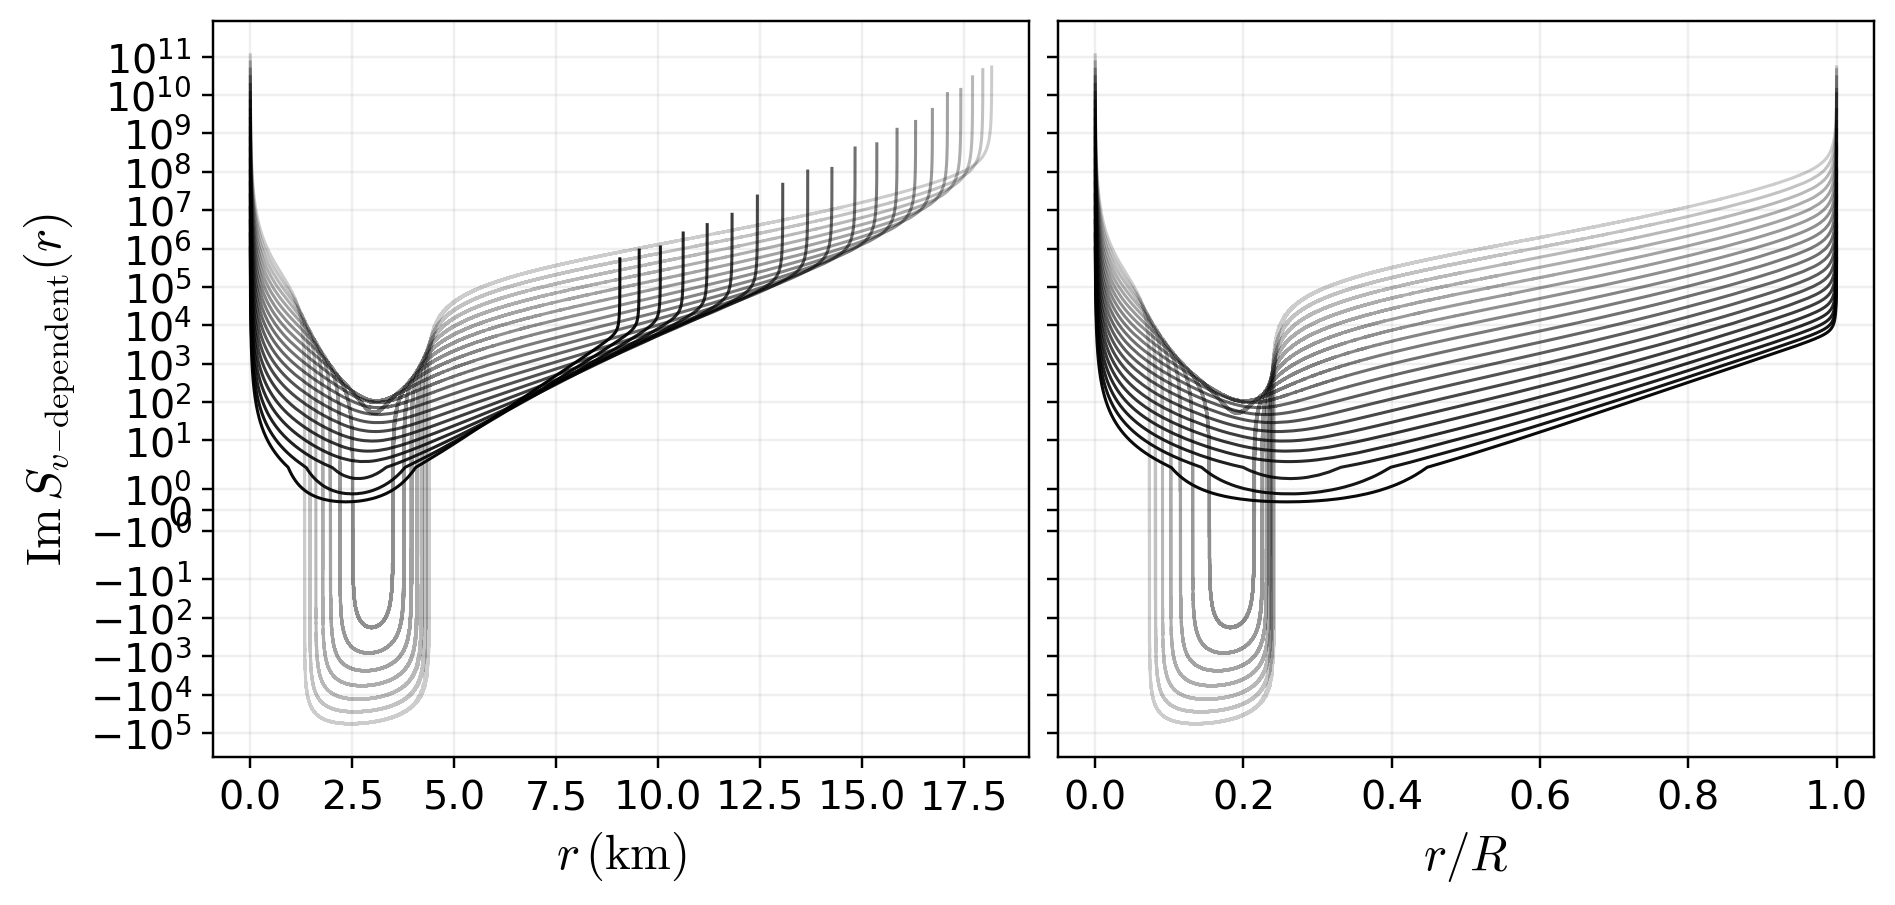

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained", sharey=True)
plt.rcParams["mathtext.fontset"] = "cm"

for nnn in range(0, 20):
    sourceOnlyV_vals = np.array(SourceOnlyVGrid[nnn])
    RArr = np.array(Rgrid[nnn])
    r_eval = RArr[:sourceOnlyV_vals.shape[0]]

    axs[0].plot(
        r_eval[5:-5],
        np.imag(sourceOnlyV_vals)[5:-5],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

    axs[1].plot(
        r_eval[5:-5] / RArr[-2],
        np.imag(sourceOnlyV_vals)[5:-5],
        lw=1,
        alpha=0.2 + nnn * 0.8 / 20,
        ls="-",
        color="black",
        zorder=5
    )

axs[0].grid(zorder=-100, alpha=0.2)
axs[0].set_xlabel("$r\,(\mathrm{km})$", fontfamily="CMU Bright", fontsize=16)
axs[0].set_ylabel("$\operatorname{Im} S_{v\mathrm{-dependent}}(r)$", fontfamily="CMU Bright", fontsize=16)

axs[1].grid(zorder=-100, alpha=0.2)
axs[1].set_xlabel("$r/R$", fontfamily="CMU Bright", fontsize=16)

for ax in axs:
    ax.set_yscale("symlog")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontsize(13)

plt.show()